# Решающие деревья

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree

from sklearn.datasets import load_iris, load_breast_cancer, make_moons

## Повторение

**Решающее дерево (Decision Tree)** — это непараметрический алгоритм, который разбивает пространство признаков на гиперпрямоугольники. В каждом узле ставится условие $x_j \leq t$, а в «листьях» записывается прогноз.

### Математическое устройство

Процесс построения — это **рекурсивное бинарное разбиение**. Мы ищем такой признак $j$ и порог $t$, которые максимизируют «чистоту» получаемых подмножеств.

### Критерий информативности $\mathbb{H}(U)$

Он измеряет уровень хаоса (неопределенности) в выборке $Q$. Чаще всего используют:

1. **Энтропия (Entropy):**  
   $$\mathbb{H}(U) = -\sum_{k=1}^K p_k \log_2 p_k$$
   

2. **Критерий Джини (Gini Impurity):**   

$$\mathbb{H}(U) = 1-\sum_{k=1}^K p_k^2 $$

(где $p_k$ — доля объектов класса $k$ в узле).

### Прирост информации (Information Gain)

Это функционал качества, который мы максимизируем при каждом разбиении:

$$IG(U, j, t) = \mathbb{H}(U) - \frac{|U_{\text{left}}|}{|U|} \mathbb{H}(U_{\text{left}}) - \frac{|U_{\text{right}}|}{|U|} \mathbb{H}(U_{\text{right}})$$

`Простыми словами`: мы вычитаем из исходного хаоса взвешенную сумму хаоса в левой и правой ветвях. Чем больше разница, тем лучше сработало разбиение.

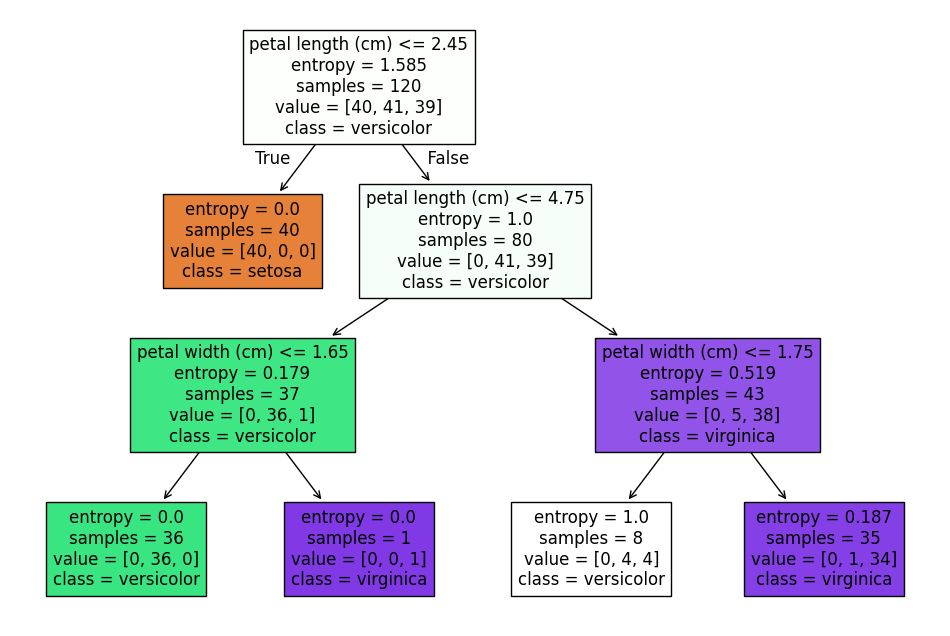

In [3]:
# 1. Загрузим данные (возьмем классический Iris)
iris = load_iris()
X, y = iris.data, iris.target

# 2. Разделим на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Инициализация и обучение
# criterion='entropy' или 'gini' (по умолчанию)
# max_depth помогает бороться с переобучением
clf = DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=42)
clf.fit(X_train, y_train)

# 4. Простая визуализация структуры
plt.figure(figsize=(12, 8))
plot_tree(clf, feature_names=iris.feature_names, class_names=iris.target_names, filled=True)
plt.show()

Помним, что решающие деревья являются высокоинтерпретируемыми моделями машинного обучения, а значит мы легко сможем выяснить какие именно признаки сильнее всего влияли на ответ

Мы можем узнать "важность" признаков с помощью `feature_importances_` в `sklearn`

             Feature  Importance
2  petal length (cm)    0.918114
3   petal width (cm)    0.081886
0  sepal length (cm)    0.000000
1   sepal width (cm)    0.000000


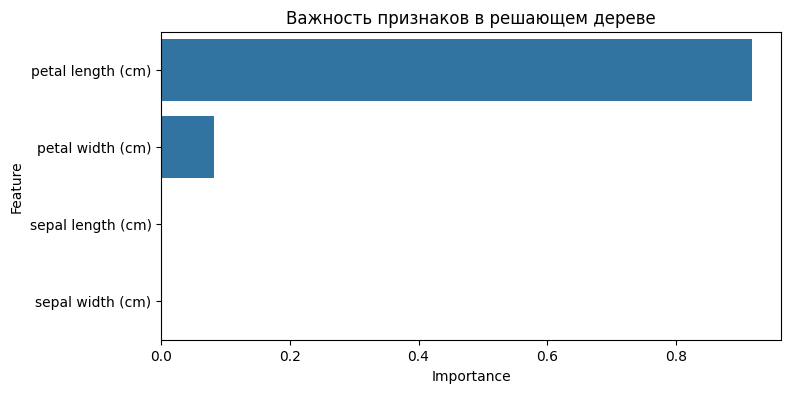

In [4]:
importances = clf.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': iris.feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title("Важность признаков в решающем дереве")
plt.show()

## Критерий Джини


Хотя оба критерия показывают схожие результаты на практике, у критерия Джини есть несколько преимуществ:

1.  **Вычислительная простота:** Формула Джини $\mathbb{H}(U) = 1-\sum_{k=1}^K p_k^2 $ не содержит логарифмов. Логарифмы — более «дорогие» операции для процессора, поэтому расчет Джини происходит быстрее, особенно при большом количестве классов $K$.

2.  **Интерпретация формы:** Критерий Джини можно интерпретировать как **вероятность ошибки** при классификации случайного объекта в данном узле. Если мы предскажем класс случайного объекта с вероятностью $p_k$, то вероятность ошибиться равна $1 - p_k$. Суммируя по всем классам, получаем именно ту формулу, что приведена выше.

3.  **Чувствительность к составу классов:**
    *   Энтропия максимальна при равномерном распределении классов, но ее график имеет более крутую форму.
    *   Критерий Джини также максимален в случае равенства классов, но он немного лучше «отслеживает» наиболее частый класс (моду), что иногда приводит к более чистым разбиениям на небольших выборках.


Оказывается, что $\mathbb{H}(U)$ можно интерпретировать и с вероятностной точки зрения:

$$\mathbb{H}(U) = \mathbb{E}(\mathcal{L}(p)) = p\mathcal{L}(p) + (1-p)\mathcal{L}(1-p)$$

где $\mathcal{L}$ -  это функция потерь для отдельного события.

Представьте, что вы достаете один объект из узла $U$ Вы еще не знаете, какой у него класс ($y=0$ или $y=1), но знаете вероятность $p$

* $\mathcal{L}$ - это ответ на вопрос: "Насколько я буду наказан (удивлен, огорчен), если достав объект, увижу, что его вероятность была $p$?"

Два класса, $Y = \{0, 1\}$, $P(y|U) = \begin{cases} p, & y=1 \\ 1-p, & y=0 \end{cases}$

- Если $\mathcal{L}(p) = -\log_2 p$, то
  $$
  Q(U) = -p \log_2 p - (1-p) \log_2 (1-p)
  $$
  — **энтропия выборки**.

- Если $\mathcal{L}(p) = 2(1-p)$, то
  $$
  Q(U) = 4p(1-p)
  $$
  — **неопределённость Джини** (Gini impurity).


![alt](../data/20.png)

In [5]:
from matplotlib.colors import ListedColormap

def plot_decision_surface(clf, X, y, title="Decision Surface"):

    X_reduced = X[:, :2]
    clf.fit(X_reduced, y)

    x_min, x_max = X_reduced[:, 0].min() - 1, X_reduced[:, 0].max() + 1
    y_min, y_max = X_reduced[:, 1].min() - 1, X_reduced[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    plt.scatter(X_reduced[:, 0], X_reduced[:, 1], c=y, edgecolors='k', cmap='viridis')
    plt.title(title)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.show()

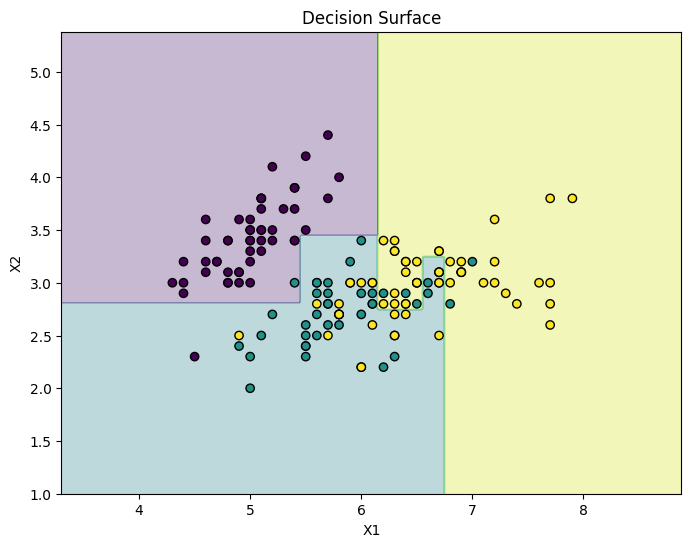

In [9]:
# Вспомним, как работает дерево визуально в признаковом пространстве
plot_decision_surface(DecisionTreeClassifier(max_depth=100, min_samples_leaf=5), X, y)

## Рекурсивный алгоритм построения дерева
Построение дерева — это процесс «разделяй и властвуй». Большинство алгоритмов (CART, ID3) работают по следующей логике:


1. **Начало:** Вся тренировочная выборка $S_0$ находится в корневом узле.
2. **Поиск лучшего сплита:** Для каждого признака $j$ и каждого порога $t$ вычисляется "хорошесть" сплита (через $IG$)
3. **Разбиение:** Выбирается пара $(j, t)$, дающая максимальный прирост информации. Данные делятся на две части $S_1=S_{left}$ и $S_2=S_{right}$ 
4. **Рекурсия:** Шаги 2 и 3 повторяются для левого и правого поддерева.
5. **Критерий остановки:** Рекурсия прекращается, если:
    * Достигнута максимальная глубина (`max_depth`).
    * В узле слишком мало объектов (`min_samples_split`).
    * Узел стал «чистым» (все объекты одного класса).
    * Прирост информации ниже порога.


### Основные исторические алгоритмы

В мире ML выделяют «династию» алгоритмов, на которых основаны современные реализации:
* `ID3 (Iterative Dichotomiser 3)`: Прародитель. Работал только с категориальными признаками, использовал Энтропию. Не умел в пропуски и регрессию.
* `C4.5`: Улучшенный ID3. Стал работать с числовыми признаками, научился «стричь» (pruning) лишние ветви и обрабатывать пропуски.
* `CART (Classification and Regression Trees)`: Именно этот алгоритм (его оптимизированная версия) реализован в `sklearn`.
    * Строит только бинарные деревья.
    * Поддерживает и классификацию (критерий Джини), и регрессию (критерий MSE/MAE).

## Гиперпараметры модели

В машинном обучении важно разделять **параметры** (которые модель учит сама, например, веса в регрессии) и **гиперпараметры** (которые задает инженер перед началом обучения).

![alt](../data/17.jpg)

**Гиперпараметры** — это внешние настройки алгоритма, которые определяют `стратегию` его обучения. Они не вычисляются в процессе минимизации ошибки, а выбираются разработчиком.


**Для чего они нужны:**

1. `Контроль сложности:` Они находят баланс между слишком простой моделью (недообучение) и слишком сложной (переобучение).
2. `Скорость обучения:` Определяют, насколько детально алгоритм будет изучать данные.
3. `Обобщающая способность:` Помогают модели хорошо работать на новых данных, а не только на тех, что она уже видела.


На примере решающего дерева посмотрим, какими бывают гиперпараметры и на что они влияют!

### Какие гиперпараметры есть у решающего дерева

В Scikit-Learn у класса DecisionTreeClassifier их много, но вот "золотая пятерка":

1. `max_depth` (Максимальная глубина)
    * Суть: Сколько уровней ветвления разрешено дереву.
    * Влияние: Чем глубже дерево, тем точнее оно подстраивается под $X_{train}$, но тем выше риск переобучения. Без ограничения дерево может расти, пока в каждом листе не останется по одному объекту.
2. `min_samples_split` (Минимальное число объектов для разбиения)
    * Суть: Сколько объектов должно быть во внутреннем узле, чтобы его можно было делить дальше.
    * Влияние: Большие значения предотвращают создание веток, которые описывают шум или случайные выбросы.
3. `min_samples_leaf` (Минимальное число объектов в листе)
    * Суть: Сколько объектов обязано остаться в итоговом "листе" после всех делений.
    * Влияние: Сильно сглаживает модель. Маленькое число (1–2) позволяет дереву создавать очень специфичные правила для крошечных групп данных.
4. `max_features` (Максимальное число признаков)
    * Суть: Сколько признаков перебирать при поиске лучшего разбиения $h$ в каждом узле.
    * Влияние: Помогает снизить переобучение и ускорить работу, если признаков в данных очень много (тысячи).
5. `criterion` (Критерий информативности)
    * Суть: `gini` или `entropy`.
    * Влияние: Как мы уже обсуждали, влияет на логику "чистоты" узлов, но на практике разница в качестве обычно минимальна.

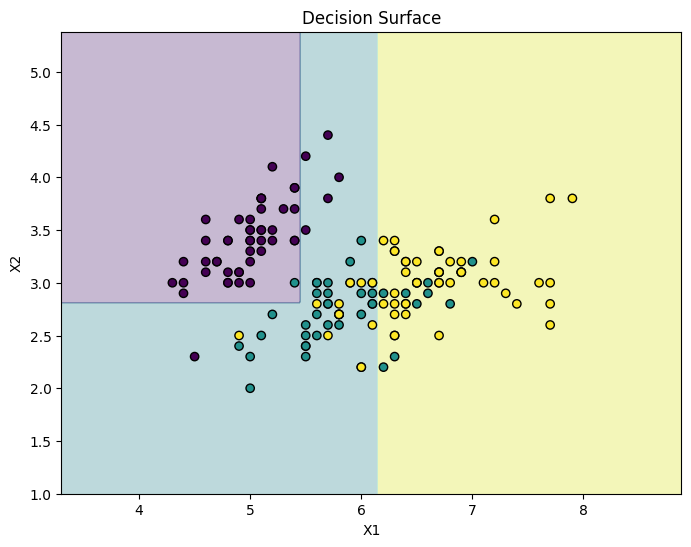

In [12]:
plot_decision_surface(DecisionTreeClassifier(max_depth=2), X, y)

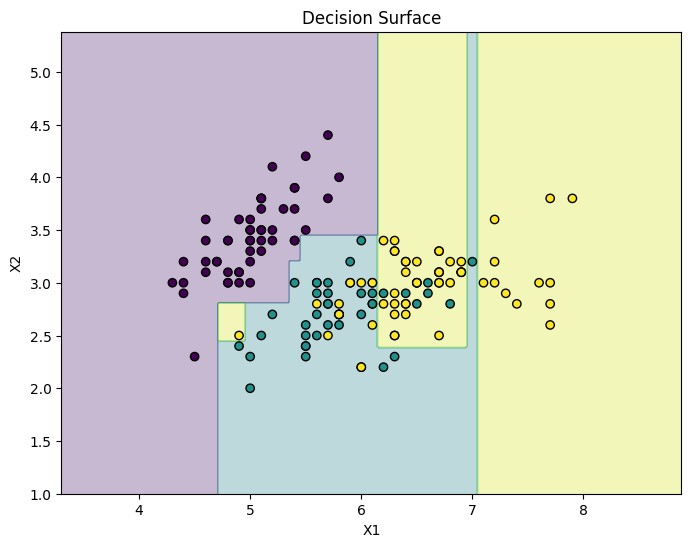

In [13]:
plot_decision_surface(DecisionTreeClassifier(max_depth=5), X, y)

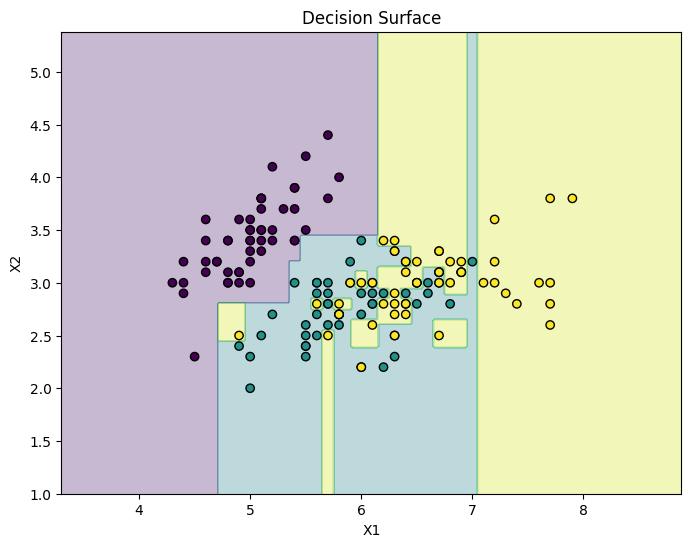

In [14]:
plot_decision_surface(DecisionTreeClassifier(max_depth=None), X, y)

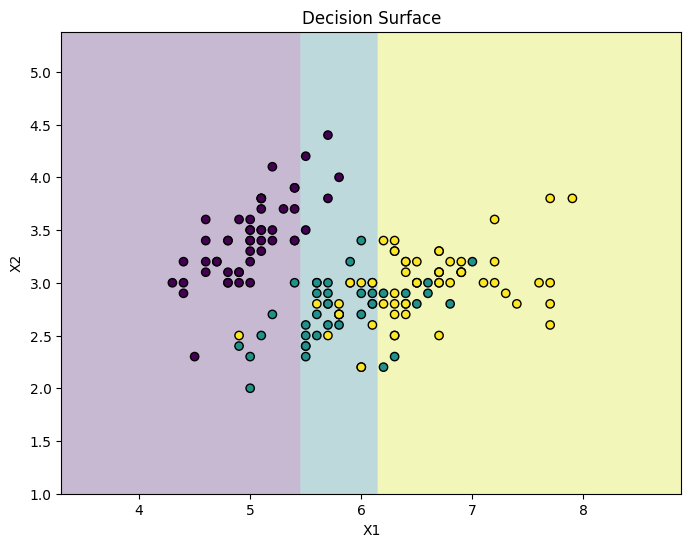

In [15]:
plot_decision_surface(DecisionTreeClassifier(min_samples_leaf=10), X, y)

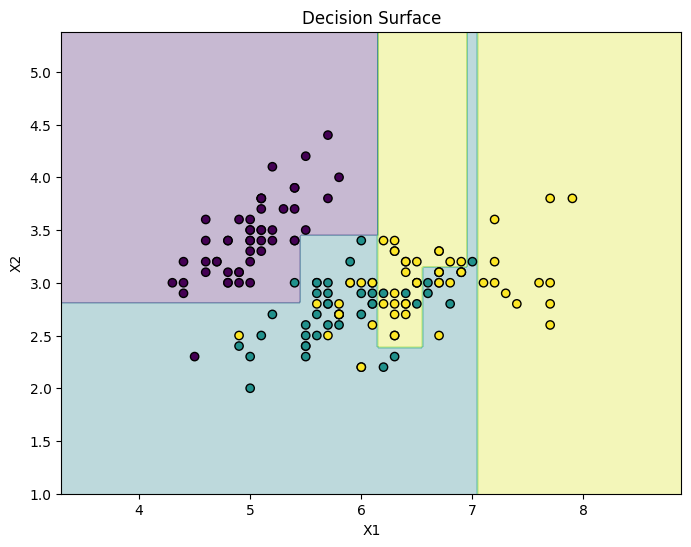

In [16]:
plot_decision_surface(DecisionTreeClassifier(min_samples_split=20), X, y)

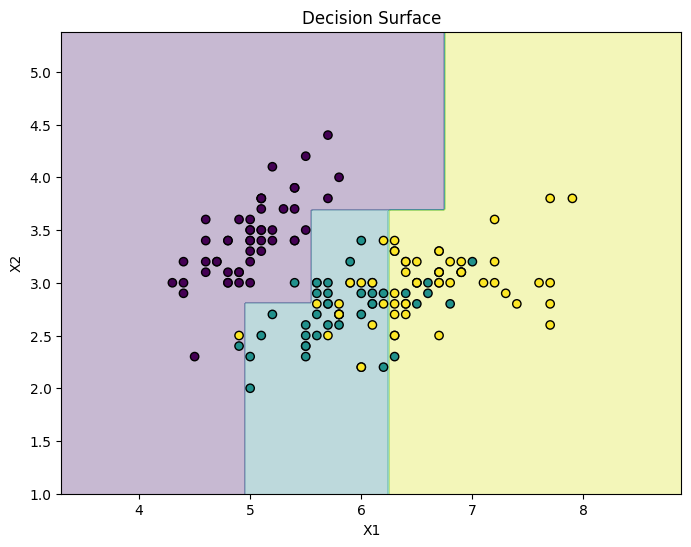

In [21]:
plot_decision_surface(DecisionTreeClassifier(criterion='entropy', max_depth=3), X, y)

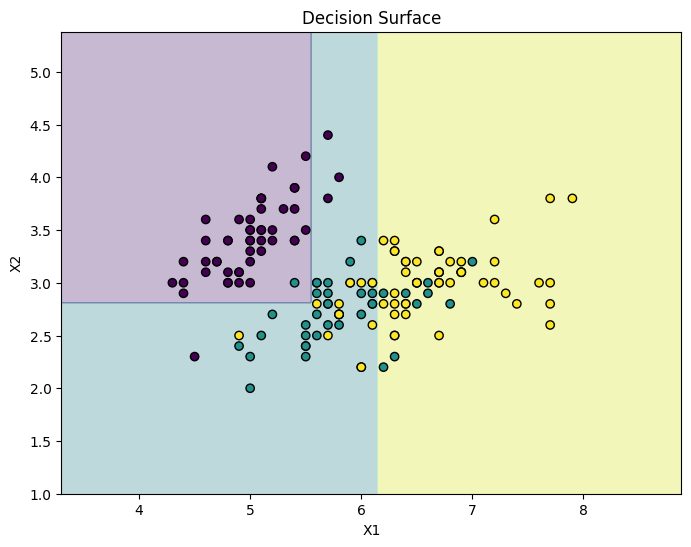

In [22]:
plot_decision_surface(DecisionTreeClassifier(
    min_samples_leaf=10,
    max_depth=3,
    criterion='entropy',
    max_features=2), X, y)


## Подбор гиперпараметров (GridSearch и RandomSearch)

Как мы поняли, качество модели может очень сильно варьироваться в зависимости от гиперпараметров, поэтому существуют разнообразные методы и инструменты для их подбора.

При этом, вне зависимости от выбранного вами метода подбора гиперпараметров, оценку и сравнение моделей нужно проводить грамотно. Пусть у нас есть несколько моделей разной природы (метод ближайших соседей, случайный лес, логистическая регрессия) или несколько нейросеток с разными архитектурами. Для каждой из моделей нужно подобрать гиперпараметры, а затем сравнить между собой модели с наилучшими гиперпараметрами.

Есть два наиболее часто используемых варианта:

* разделить выборку на тренировочную, валидационную и тестовую части;
* провести кросс-валидацию.

### Первый вариант

Если мы делим выборку только на тренировочную и тестовую части, в модель через подобранные гиперпараметры просачивается информация о тестовой выборке. Это означает, что на новых данных модели могут не сохранить свои качества и что их сравнение не будет честным.

Поэтому предлагается разделить выборку на тренировочную, валидационную и тестовую части, для каждой модели выбирать гиперпараметры, максимизирующие её метрики на валидации, а окончательное сравнение моделей проводить по тестовым метрикам.

Валидационная выборка (`Validation set`) — это «промежуточный экзамен» для модели. Это часть данных, которую мы откладываем в сторону и не используем для обучения весов, но используем для подбора гиперпараметров (например, той же глубины дерева).

![alttext](../data/17.webp)

### Второй вариант

Провести кросс-валидацию.

Кросс-валидация может быть нужна в случаях, если данных мало или мы не хотим зависеть от конкретного выбора валидационного множества. Примерный алгоритм:

* зафиксировать некоторое тестовое множество и отложить его;

* разделить оставшееся множество данных на $k$ фолдов (подмножеств), пройтись по ним циклом, на каждой итерации фиксируя один фолд в качестве валидационного и обучаясь на остальных;

* как оценку качества модели взять среднее значение валидационной метрики по фолдам;

* финальное сравнение моделей с уже подобранными гиперпараметрами проводить на отложенном тестовом множестве.

![alttext](../data/18.webp)

### Самый базовый метод: Grid Search

Самый естественный способ организовать перебор наборов гиперпараметров — сделать перебор по сетке (англ. Grid Search):

1. для каждого гиперпараметра фиксируется несколько значений;

2. перебираются все комбинации значений различных гиперпараметров, на каждой из этих комбинаций модель обучается и тестируется;

3. выбирается комбинация, на которой модель показывает лучшее качество.

In [23]:
from sklearn.model_selection import GridSearchCV

# 1. Определяем сетку параметров, которые хотим протестировать
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [2, 3, 4, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5]
}

# 2. Инициализируем поиск (cv=5 означает 5-фолдовую кросс-валидацию)
grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=10,
    scoring='accuracy'
)

# 3. Запускаем обучение на тренировочных данных
grid_search.fit(X_train, y_train)

# 4. Выводим результаты
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшая Accuracy на кросс-валидации: {grid_search.best_score_:.4f}")

# 5. Оцениваем итоговую модель на отложенном тесте
best_model = grid_search.best_estimator_
test_acc = best_model.score(X_test, y_test)
print(f"Accuracy на тестовой выборке: {test_acc:.4f}")

Лучшие параметры: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 10}
Лучшая Accuracy на кросс-валидации: 0.9417
Accuracy на тестовой выборке: 1.0000


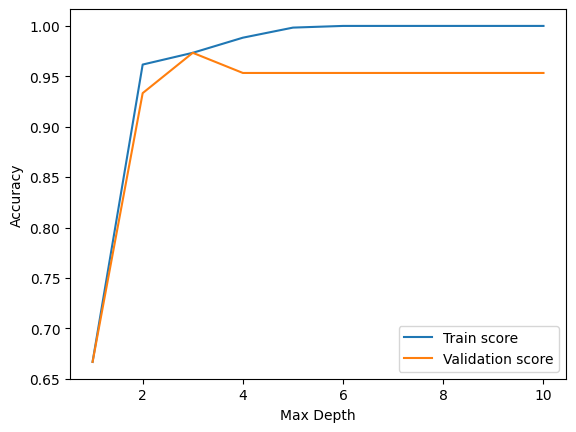

In [24]:
from sklearn.model_selection import validation_curve

depths = np.arange(1, 11)
train_scores, val_scores = validation_curve(
    DecisionTreeClassifier(random_state=42), X, y,
    param_name="max_depth", param_range=depths, cv=5
)

plt.plot(depths, np.mean(train_scores, axis=1), label="Train score")
plt.plot(depths, np.mean(val_scores, axis=1), label="Validation score")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## Регуляризация деревьев

Регуляризация — это способ заставить дерево «не жадничать» и не пытаться идеально выучить каждую точку тренировочного набора. Без неё дерево просто запомнит шум, что приведет к переобучению (высокая точность на $X_{train}$, низкая — на $X_{test}$).
В контексте решающих деревьев выделяют два подхода: Pre-pruning (остановка до того, как дерево выросло) и Post-pruning (обрезка уже готового дерева).

### Pre-pruning (Предварительная остановка)
Это основной метод в библиотеке `sklearn`. Мы задаем ограничения в виде гиперпараметров до начала обучения.

**Математически** это эквивалентно добавлению штрафа за сложность структуры дерева.

### Post-pruning (Обрезка веток)

Этот метод классически использовался в алгоритмах C4.5 и CART. Сначала мы даем дереву вырасти до максимума, а затем «отсекаем» ветви, которые не дают значимого прироста точности на валидации.

В `sklearn` это реализовано через Minimal Cost-Complexity Pruning (параметр `ccp_alpha`).

**Математически** это означает, что мы штрафуем модель:

$$\mathcal{L}_{\alpha}(T) = \mathcal{L}(T) + \alpha|T|$$



В алгоритме обрезки по минимальной цене (minimal cost complexity pruning), являющегося составной частью алгоритма CARTдерево строится до самого низа (хотя также можно применять досрочный останов, например, по минимальному числу объектов в листьях), после чего для каждой внутренней вершины полного дерева оценивается целесообразность разрастания вершины до поддерева, сравнивая 2 ситуации:

1. когда эта вершина имеет под собой исходное поддерево;

2. когда эта вершина является терминальной (без поддерева под ним).

Эти ситуации проиллюстрированы ниже для вершины  $t$

![alt](../data/19.png)

## Практика

**Условия задачи:**
1. Загрузить данные (мы возьмем упрощенную версию из библиотеки seaborn).
2. Провести базовую предобработку (деревья в sklearn не умеют работать со строками и пропуски нужно заполнить).
3. Обучить DecisionTreeClassifier.
4. Подобрать оптимальную глубину дерева (`max_depth`), чтобы избежать переобучения.
5. Визуализировать самое важное правило, которое нашло дерево.


In [ ]:
import seaborn as sns

df = sns.load_dataset('titanic')

features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']
X = df[features]
y = df['survived']

# Твой код

In [25]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
